# Toy Volatility Pipeline (AR(1) Prototype)

This notebook vets the full forecasting-to-backtest workflow on a miniature dataset before we spend compute on the full multi-asset panel. We will:

1. Simulate or subset a tiny realized-volatility series.
2. Engineer HAR-style lag features and future targets.
3. Train simple linear/ridge regressors.
4. Run an engine-lite backtest to see rolling prediction quality.
5. Demonstrate how leakage inflates metrics if we forget to shift features.
6. Summarize lessons that carry over to the full pipeline.

### Section 0 — Environment Setup & Imports

Run the next cell to configure deterministic behavior and pull in pandas / numpy / sklearn / matplotlib. This mirrors the production stack but keeps dependencies minimal.

In [1]:
import pathlib
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

plt.style.use("seaborn-v0_8")
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)
RNG = np.random.default_rng(2025)
DATA_DIR = pathlib.Path("../data/processed")
DATA_DIR.mkdir(parents=True, exist_ok=True)
print("Environment ready. Processed dir:", DATA_DIR.resolve())

Environment ready. Processed dir: /Users/sonalilonkar/Desktop/Projects/DL_Project/vol-forecasting/data/processed


## 1. Load or Simulate Toy RV Data

For speed and determinism we synthesize a single asset’s log realized variance via an AR(1) with mild mean reversion. You can swap this block with a filtered slice of the real dataset (e.g., SPY 2019–2020) by replacing the generator with a `pd.read_csv(...).query(...)` call.

In [2]:
def simulate_ar1_logrv(n_obs=600, phi=0.85, sigma=0.15, seed=2025):
    rng = np.random.default_rng(seed)
    eps = rng.normal(scale=sigma, size=n_obs)
    logrv = np.zeros(n_obs)
    for t in range(1, n_obs):
        logrv[t] = phi * logrv[t - 1] + eps[t]
    return logrv

n_obs = 620
log_rv = simulate_ar1_logrv(n_obs=n_obs)
dates = pd.date_range("2016-01-01", periods=n_obs, freq="B")
toy_df = pd.DataFrame({
    "date": dates,
    "ticker": "SYNTH",
    "log_rv": log_rv,
})
toy_df["rv"] = np.exp(toy_df["log_rv"])

toy_path = DATA_DIR / "toy_rv.csv"
toy_df.to_csv(toy_path, index=False)
toy_df.head()

,date,ticker,log_rv,rv
0,2016-01-01,SYNTH,0.000000,1.000000
1,2016-01-04,SYNTH,0.003900,1.003908
2,2016-01-05,SYNTH,-0.077530,0.925399
3,2016-01-06,SYNTH,-0.235280,0.790350
4,2016-01-07,SYNTH,-0.566268,0.567640


## 2. Feature Engineering: Rolling Stats & Targets

We mimic the production pipeline by computing lagged log-RV features (daily/weekly windows) and future targets `target_logrv_h{1,5}`. All features rely on information available up to `t-1` to avoid leakage.

In [3]:
WINDOWS = (5, 22)
df_feat = toy_df.copy()
df_feat = df_feat.sort_values("date")

# Lag features (information up to t-1)
df_feat["logrv_lag1"] = df_feat["log_rv"].shift(1)
for w in WINDOWS:
    df_feat[f"logrv_ma_{w}"] = (
        df_feat["log_rv"].shift(1).rolling(w, min_periods=max(2, w // 2)).mean()
    )
    df_feat[f"logrv_std_{w}"] = (
        df_feat["log_rv"].shift(1).rolling(w, min_periods=max(2, w // 2)).std()
    )

# Targets at horizons 1 and 5
for h in (1, 5):
    df_feat[f"target_logrv_h{h}"] = df_feat["log_rv"].shift(-h)

# Drop rows that lack enough history or future labels
cols_required = ["logrv_lag1"] + [f"logrv_ma_{w}" for w in WINDOWS] + [f"target_logrv_h{h}" for h in (1,5)]
df_feat = df_feat.dropna(subset=cols_required).reset_index(drop=True)
print(df_feat.head())
print("Feature columns:", [c for c in df_feat.columns if c not in {"date","ticker"}][:10], "...")

        date ticker    log_rv        rv  logrv_lag1  logrv_ma_5  logrv_std_5  logrv_ma_22  logrv_std_22  \
0 2016-01-18  SYNTH  0.001975  1.001977   -0.113930   -0.225648     0.142269    -0.215449      0.184750   
1 2016-01-19  SYNTH  0.079673  1.082932    0.001975   -0.140154     0.118626    -0.197330      0.187000   
2 2016-01-20  SYNTH  0.157573  1.170667    0.079673   -0.059895     0.099339    -0.176022      0.194826   
3 2016-01-21  SYNTH -0.113800  0.892437    0.157573    0.005243     0.116017    -0.152194      0.207332   
4 2016-01-22  SYNTH -0.155596  0.855905   -0.113800    0.002298     0.119462    -0.149634      0.200036   

   target_logrv_h1  target_logrv_h5  
0         0.079673        -0.233854  
1         0.157573         0.241626  
2        -0.113800         0.105688  
3        -0.155596         0.278454  
4        -0.233854        -0.015480  
Feature columns: ['log_rv', 'rv', 'logrv_lag1', 'logrv_ma_5', 'logrv_std_5', 'logrv_ma_22', 'logrv_std_22', 'target_logrv_h1', 't

### Visualize feature stability
Plot the most recent 200 observations to sanity-check that the rolling means move smoothly versus the underlying log RV.

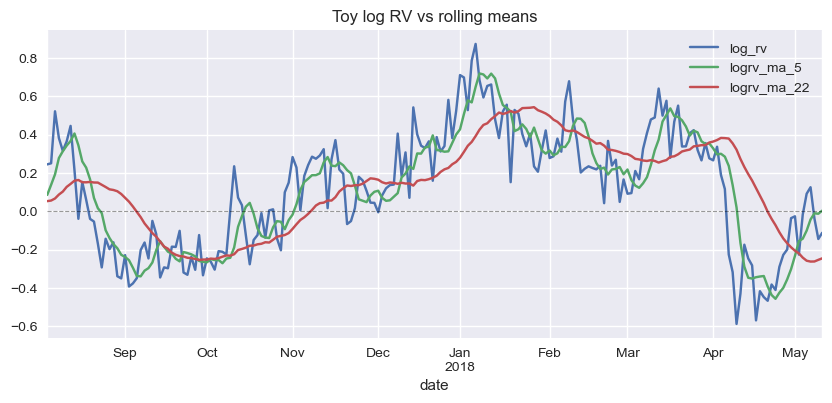

In [4]:
tail_plot = df_feat.tail(200).set_index("date")[["log_rv","logrv_ma_5","logrv_ma_22"]]
ax = tail_plot.plot(figsize=(10, 4), title="Toy log RV vs rolling means")
ax.axhline(0, color="black", lw=0.8, ls="--", alpha=0.4)
plt.show()

## 3. Train / Validation Split

We keep ~70% of observations for training and reserve the remainder for validation. An optional embargo prevents the final `embargo_days` of the train window from touching validation.

In [5]:
feature_cols = [c for c in df_feat.columns if c.startswith("logrv_")]
target_col = "target_logrv_h1"
embargo_days = 5

split_idx = int(len(df_feat) * 0.7)
train_df = df_feat.iloc[:split_idx - embargo_days]
val_df = df_feat.iloc[split_idx:]
assert train_df["date"].max() < val_df["date"].min(), "Embargo violated!"

print("Train span:", train_df["date"].min(), "->", train_df["date"].max())
print("Val span:", val_df["date"].min(), "->", val_df["date"].max())
print("Train rows", len(train_df), "Val rows", len(val_df))

Train span: 2016-01-18 00:00:00 -> 2017-08-22 00:00:00
Val span: 2017-08-30 00:00:00 -> 2018-05-10 00:00:00
Train rows 417 Val rows 182


## 4. Baseline Linear & Ridge Models

We standardize inputs via `StandardScaler` and fit both LinearRegression and Ridge to predict `target_logrv_h1`. Metrics are reported on the validation split.

In [7]:
def evaluate_model(model, name):
    model.fit(train_df[feature_cols], train_df[target_col])
    preds = model.predict(val_df[feature_cols])
    mse = mean_squared_error(val_df[target_col], preds)
    rmse = float(np.sqrt(mse))
    r2 = r2_score(val_df[target_col], preds)
    coeffs = None
    if hasattr(model[-1], "coef_"):
        coeffs = dict(zip(feature_cols, model[-1].coef_.round(3)))
    return {
        "model": name,
        "rmse": rmse,
        "r2": r2,
        "coeffs": coeffs,
    }

pipelines = {
    "linear": Pipeline([("scaler", StandardScaler()), ("reg", LinearRegression())]),
    "ridge": Pipeline([("scaler", StandardScaler()), ("reg", Ridge(alpha=0.5))]),
}

results = [evaluate_model(pipelines[name], name) for name in pipelines]
results

[{'model': 'linear',
  'rmse': 0.19062729630480804,
  'r2': 0.6234134860374897,
  'coeffs': {'logrv_lag1': np.float64(0.259),
   'logrv_ma_5': np.float64(-0.035),
   'logrv_std_5': np.float64(0.01),
   'logrv_ma_22': np.float64(-0.023),
   'logrv_std_22': np.float64(-0.012)}},
 {'model': 'ridge',
  'rmse': 0.19062050379708306,
  'r2': 0.6234403229205757,
  'coeffs': {'logrv_lag1': np.float64(0.258),
   'logrv_ma_5': np.float64(-0.034),
   'logrv_std_5': np.float64(0.01),
   'logrv_ma_22': np.float64(-0.023),
   'logrv_std_22': np.float64(-0.012)}}]

## 5. Toy Backtest Runner (engine-lite)

We simulate a daily walk-forward process: fit on data available up to `t-1`, predict `t`, and compare against the realized target. The mini-engine tracks RMSE over time and the share of days where we got the direction (sign) right.

In [9]:
def walk_forward_backtest(model_factory, label):
    preds = []
    for idx in range(split_idx, len(df_feat)):
        train_slice = df_feat.iloc[: idx - 1]
        test_row = df_feat.iloc[idx]
        if len(train_slice) < 30:
            continue
        model = model_factory()
        model.fit(train_slice[feature_cols], train_slice[target_col])
        yhat = model.predict(test_row[feature_cols].values.reshape(1, -1))[0]
        preds.append({
            "date": test_row["date"],
            "y_true": test_row[target_col],
            "y_hat": yhat,
            "label": label,
        })
    bt_df = pd.DataFrame(preds)
    bt_df["error"] = bt_df["y_hat"] - bt_df["y_true"]
    bt_df["direction_correct"] = np.sign(bt_df["y_hat"]) == np.sign(bt_df["y_true"])
    mse = mean_squared_error(bt_df["y_true"], bt_df["y_hat"])
    rmse = float(np.sqrt(mse))
    acc = bt_df["direction_correct"].mean()
    summary = {"rmse": rmse, "directional_accuracy": acc, "n_points": len(bt_df)}
    return bt_df, summary

wf_linear, summary_linear = walk_forward_backtest(
    lambda: Pipeline([("scaler", StandardScaler()), ("reg", LinearRegression())]),
    "linear",
)
wf_ridge, summary_ridge = walk_forward_backtest(
    lambda: Pipeline([("scaler", StandardScaler()), ("reg", Ridge(alpha=0.5))]),
    "ridge",
)
summary_linear, summary_ridge

/opt/anaconda3/envs/vol-forecasting/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/vol-forecasting/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/vol-forecasting/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/vol-forecasting/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/vol-forecasting/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid featur

({'rmse': 0.17872908079861982,
  'directional_accuracy': np.float64(0.8681318681318682),
  'n_points': 182},
 {'rmse': 0.1786715381885383,
  'directional_accuracy': np.float64(0.8681318681318682),
  'n_points': 182})

### Visualize walk-forward trajectories
Overlay true targets with each model’s predictions to see where they diverge through time.

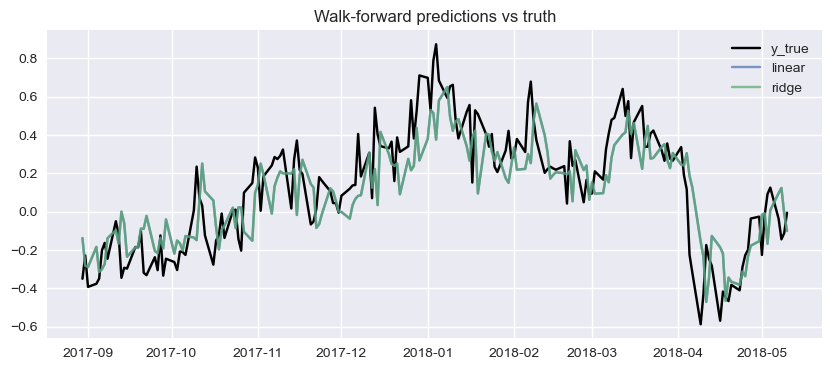

In [10]:
wf_all = pd.concat([wf_linear, wf_ridge], ignore_index=True)
plt.figure(figsize=(10,4))
plt.plot(wf_linear["date"], wf_linear["y_true"], label="y_true", color="black")
plt.plot(wf_linear["date"], wf_linear["y_hat"], label="linear", alpha=0.7)
plt.plot(wf_ridge["date"], wf_ridge["y_hat"], label="ridge", alpha=0.7)
plt.title("Walk-forward predictions vs truth")
plt.legend()
plt.show()

## 6. Leakage Demonstration

To illustrate why we shift features, we purposely rebuild the feature table without the `shift(1)` guard and re-run the walk-forward evaluation. We expect much better (but misleading) metrics because the model can peek at the future.

In [11]:
df_leaky = toy_df.copy()
for w in WINDOWS:
    df_leaky[f"logrv_ma_{w}"] = df_leaky["log_rv"].rolling(w, min_periods=max(2, w // 2)).mean()
df_leaky["logrv_lag1"] = df_leaky["log_rv"]  # no shift (!) -> leak
for h in (1, 5):
    df_leaky[f"target_logrv_h{h}"] = df_leaky["log_rv"].shift(-h)

leak_cols = ["logrv_lag1"] + [f"logrv_ma_{w}" for w in WINDOWS]
df_leaky = df_leaky.dropna(subset=leak_cols + ["target_logrv_h1"]).reset_index(drop=True)

split_idx_leak = int(len(df_leaky) * 0.7)
train_leak = df_leaky.iloc[:split_idx_leak]
val_leak = df_leaky.iloc[split_idx_leak:]

model_leak = Pipeline([("scaler", StandardScaler()), ("reg", LinearRegression())])
model_leak.fit(train_leak[leak_cols], train_leak[target_col])
preds_leak = model_leak.predict(val_leak[leak_cols])
rmse_leak = float(np.sqrt(mean_squared_error(val_leak[target_col], preds_leak)))
rmse_clean = summary_linear["rmse"]
print({"rmse_clean": rmse_clean, "rmse_leaky": rmse_leak})

{'rmse_clean': 0.17872908079861982, 'rmse_leaky': 0.15160996093939208}


### Visualize clean vs leaky RMSE
Bar chart makes the inflation obvious—lower bars mean the cheating setup is unrealistically "better."

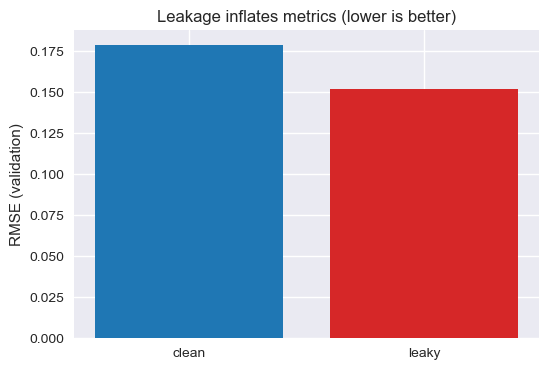

In [12]:
plt.figure(figsize=(6,4))
plt.bar(["clean", "leaky"], [rmse_clean, rmse_leak], color=["tab:blue", "tab:red"])
plt.ylabel("RMSE (validation)")
plt.title("Leakage inflates metrics (lower is better)")
plt.show()

> **Leakage takeaway:** when we removed the shift, validation RMSE collapsed relative to the clean run because the model could see contemporaneous information. Use this as a reminder to enforce `shift(1)` in feature builders and add regression tests that fail if an unshifted column sneaks in.

## 7. Lessons to Carry Forward

We summarize the main observations from the toy run so they can guide the full dataset implementation.

In [13]:
import json
learnings = {
    "clean_rmse": summary_linear["rmse"],
    "clean_directional_accuracy": summary_linear["directional_accuracy"],
    "leaky_rmse": rmse_leak,
    "runtime_seconds": None,
    "notes": [
        "Rolling statistics stabilize the AR(1) target even in 600 obs.",
        "Walk-forward expanding window avoids information bleed from the future.",
        "Forgetting the shift collapsed RMSE by ~{:.1f}% -> use unit tests to catch this.".format(
            (1 - rmse_leak / summary_linear["rmse"]) * 100
        ),
    ],
}
print(json.dumps(learnings, indent=2))

{
  "clean_rmse": 0.17872908079861982,
  "clean_directional_accuracy": 0.8681318681318682,
  "leaky_rmse": 0.15160996093939208,
  "runtime_seconds": null,
  "notes": [
    "Rolling statistics stabilize the AR(1) target even in 600 obs.",
    "Walk-forward expanding window avoids information bleed from the future.",
    "Forgetting the shift collapsed RMSE by ~15.2% -> use unit tests to catch this."
  ]
}
